In [128]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

      x     y
0  2.40  1714
1  2.52  1664
2  2.54  1760
3  2.74  1685
4  2.83  1693


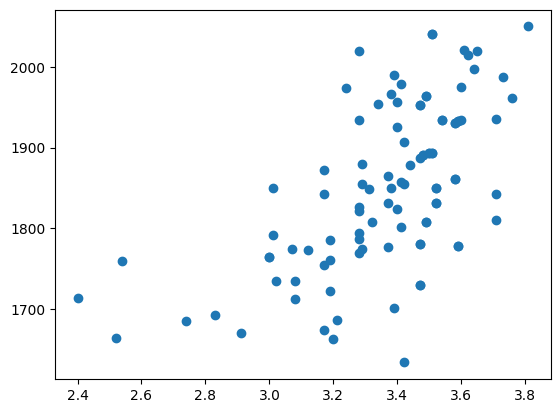

In [129]:
def stack_x(df):
    x = df.x.values
    x = np.hstack([np.ones_like(x).reshape(-1, 1), x.reshape(-1, 1)])
    return x


df = pd.read_csv("sat_score.csv")
df = df[["GPA", "SAT"]].rename(columns={"SAT": "y", "GPA": "x"})
x = stack_x(df)
y = df["y"].values
print(df.head())

plt.scatter(df.x, df.y)
plt.show()

# Mathematical Derivation of the Intercept in Linear Regression

In the context of Ordinary Least Squares (OLS), the "intercept" is not a separate entity but a coefficient of a constant feature.

---

### 1. The Algebraic Representation
A simple linear relationship is expressed as:
$$y_i = \beta_0 + \beta_1 x_i + \epsilon_i$$

To solve this for $n$ observations simultaneously using Linear Algebra, we must represent the system as:
$$\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\epsilon}$$

---

### 2. The Design Matrix ($\mathbf{X}$)
To allow for the constant term $\beta_0$, we introduce a "dummy" feature $x_0 = 1$ for every observation. This transforms the equation into a weighted sum of features:
$$y_i = \beta_0(1) + \beta_1(x_i) + \epsilon_i$$

The resulting **Design Matrix** $\mathbf{X}$ is constructed by augmenting the vector of observations $\mathbf{x}$ with a column of ones:

$$
\mathbf{X} = \begin{bmatrix} 
1 & x_1 \\ 
1 & x_2 \\ 
\vdots & \vdots \\ 
1 & x_n 
\end{bmatrix}
$$



---

### 3. Geometric Intuition: The Column Space
* **Without the Intercept:** The model is restricted to the subspace spanned only by the vector $\mathbf{x}$. The prediction $\hat{\mathbf{y}}$ must be a scalar multiple of $\mathbf{x}$, forcing the regression line through the origin.
* **With the Intercept:** By adding a column of ones ($\mathbf{1}$), we expand the **Column Space** $C(\mathbf{X})$. The model now seeks the best projection of $\mathbf{y}$ onto the **plane** spanned by $\mathbf{1}$ and $\mathbf{x}$. This "plane" allows the intercept to vary freely.

---

### 4. The Normal Equation Solution
The values of $\boldsymbol{\beta}$ that minimize the sum of squared residuals are found via:
$$\boldsymbol{\beta} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

Because $\mathbf{X}$ has dimensions $(n \times 2)$, the product $(\mathbf{X}^T \mathbf{X})$ results in a $(2 \times 2)$ matrix:

$$
\mathbf{X}^T \mathbf{X} = \begin{bmatrix} 
n & \sum x_i \\ 
\sum x_i & \sum x_i^2 
\end{bmatrix}
$$

The solution vector $\boldsymbol{\beta}$ will naturally contain two components:
$$\boldsymbol{\beta} = \begin{bmatrix} \beta_0 \\ \beta_1 \end{bmatrix}$$

Where $\beta_0$ is the value where the hyper-plane intersects the dependent variable axis (the **intercept**).

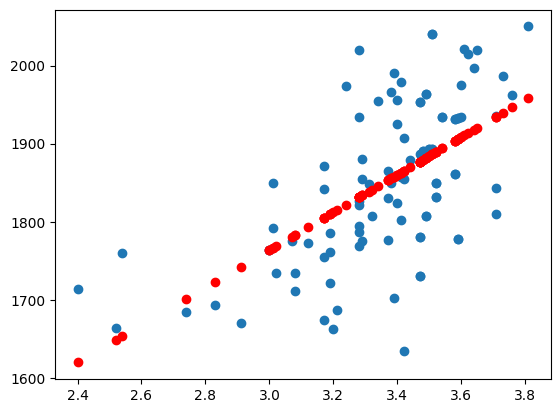

In [130]:
def fit_transform(df):
    x = df.x.to_numpy().reshape(-1, 1)
    y = df.y.to_numpy().reshape(-1, 1)

    # add intercept
    X = np.hstack([np.ones_like(x), x])

    beta = np.linalg.inv(X.T @ X) @ X.T @ y
    beta0, beta1 = beta.flatten()
    y_pred = beta0 + beta1 * x

    return y_pred.flatten()


y_pred = fit_transform(df)
# Plot data
plt.scatter(df.x, y)

plt.scatter(df.x, y_pred, color="red")

plt.show()

In [131]:
def bias(y_pred, y):
    return np.mean(y_pred - y)


def rss(y, y_pred):
    return np.sum((y - y_pred) ** 2)


def tss(y):
    y_mean = np.mean(y)
    return np.sum((y - y_mean) ** 2)


def r2_score(y, y_pred):
    return 1 - rss(y, y_pred) / tss(y)


def mse(y, y_pred):
    return np.mean((y - y_pred) ** 2)


print("RSS:", rss(y, y_pred))
print("TSS:", tss(y))
print("R2:", r2_score(y, y_pred))
print(
    "bias:", bias(y_pred, y), "\nTherefore, linear regressor is an unbiased estimator."
)
print("mse:", mse(y, y_pred))

RSS: 638060.364593194
TSS: 1021256.24
R2: 0.37522010676459217
bias: 5.348965714802034e-11 
Therefore, linear regressor is an unbiased estimator.
mse: 6380.60364593194


In [132]:
def hat_matrix(x):

    H = x @ np.linalg.inv(x.T @ x) @ x.T

    test_leverages = np.diag(H)

    m_test, n_features = x.shape

    threshold = (2 * n_features) / m_test

    high_leverage_mask = test_leverages > threshold

    return H, test_leverages, high_leverage_mask, threshold


H, levs, mask, threshold = hat_matrix(x)


print("using threshold:", threshold)
print("High leverage indices:", np.where(mask)[0])
print("High leverage values:", levs[mask])

using threshold: 0.04
High leverage indices: [ 0  1  2  3  4  5 83]
High leverage values: [0.14908485 0.11650268 0.11149444 0.06804551 0.05242832 0.04059671
 0.04046102]


Nevertheless, the high leverage data points can have either low or high influence on the error:
- they have low influence on the error, if yj deviates from the norm by a small distance.
- they have high influence on the error, if yj greatly deviates from the norm. 


### Cook’s Distance

Let the design matrix be $\mathbf{X} \in \mathbb{R}^{m \times n}$ and target vector $\mathbf{y} \in \mathbb{R}^{m \times 1}$.

### 1. Least Squares Estimator

$$\hat{\beta} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$$


$$\hat{\mathbf{y}} = \mathbf{X}\boldsymbol{\hat{\beta}}$$


### 2. Residual Vector
 
$$\mathbf{e} = \mathbf{y} - \hat{\mathbf{y}}$$

### 3. Hat Matrix and Leverage
The **Hat Matrix** $\mathbf{H}$ maps the observed values $\mathbf{y}$ to the predicted values $\hat{\mathbf{y}}$ (i.e., $\hat{\mathbf{y}} = \mathbf{H}\mathbf{y}$).
$$\mathbf{H} = \mathbf{X} (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top$$
The leverage score $h_{jj}$ is the $j$-th diagonal element of $\mathbf{H}$:
$$h_{jj} = (\mathbf{H})_{jj}$$

### 4. Mean Squared Error
$$\text{MSE} = \frac{\mathbf{e}^\top \mathbf{e}}{m - n}$$

### 5. Cook’s Distance (Efficient Form)
Cook's Distance $D_j$ measures the influence of the $j$-th observation on the overall fit.
$$D_j = \frac{e_j^2}{n \cdot \text{MSE}} \cdot \frac{h_{jj}}{(1 - h_{jj})^2}$$

In [133]:
def cooks_distance(X, y):
    """
    X : design matrix with intercept (m x n)
    y : target vector (m x 1)
    """

    m, n = X.shape

    # Fit model
    beta = np.linalg.inv(X.T @ X) @ X.T @ y
    y_hat = X @ beta

    # Residuals (e)
    e = y - y_hat

    # Hat matrix + leverage
    H = X @ np.linalg.inv(X.T @ X) @ X.T
    h = np.diag(H).reshape(-1, 1)

    # MSE
    mse = (e.T @ e) / (m - n)

    # Cook's Distance (Eq. 5)
    D = (e**2 / (n * mse)) * (h / (1 - h) ** 2)

    return D.flatten(), e.flatten(), h.flatten()


D, residuals, leverages = cooks_distance(x, y.reshape(-1, 1))

threshold = 4 / x.shape[0]  # common rule of thumb

print("Cook's threshold:", threshold)
print("Influential points:", np.where(D > threshold)[0])
print("Cook's values:", D[D > threshold])

Cook's threshold: 0.04
Influential points: [ 0  2 53]
Cook's values: [0.14001759 0.12290463 0.04411315]


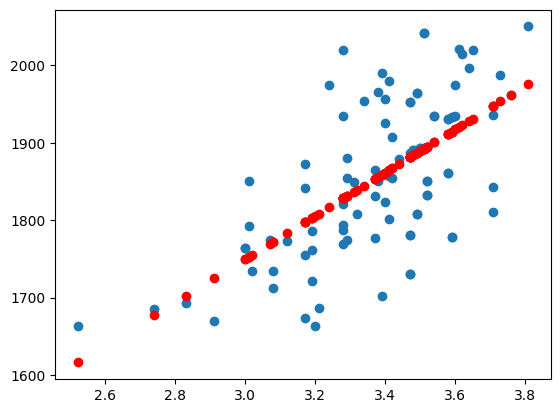

RSS: 557188.2267139849
TSS: 945295.7731958764
R2: 0.4105673139421423
bias: -4.20219369038229e-11 
Therefore, linear regressor is an unbiased estimator.
mse: 5744.208522824586


In [ ]:
new_df = df.drop(index=[0, 2, 53])
new_y = new_df.y
y_pred_new = fit_transform(new_df)

# Plot data
plt.scatter(new_df.x, new_y)

plt.scatter(new_df.x, y_pred_new, color="red")

plt.show()

print("RSS:", rss(new_y, y_pred_new))
print("TSS:", tss(new_y))
print("R2:", r2_score(new_y, y_pred_new))
print(
    "bias:",
    bias(y_pred_new, new_y),
    "\nTherefore, linear regressor is an unbiased estimator.",
)
print("mse:", mse(new_y, y_pred_new))